In [1]:
import time
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

from goodpoints import compress
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders
import sage
import shap

np.random.seed(0)

ground_truth_repeat = 2
cte_repeat = 5


data_name = 'heloc'

_, loader_test = ReturnLoaders(data_name=data_name, download=False, batch_size=128)
X_test, y_test = loader_test.dataset.data, loader_test.dataset.targets.to_numpy()

n_samples_total = X_test.shape[0]
n_features = X_test.shape[1]

values_cte_path = f'../metadata/{data_name}/cte_shap_sage_results_0_{cte_repeat}.npy'
times_cte_info_path = f'../metadata/{data_name}/cte_shap_sage_times_0_{cte_repeat}.csv'

values_gt_path = f'../metadata/{data_name}/ground_truth_shap_sage_results_0_{ground_truth_repeat}.npy'
# times_gt_info_path = f'../metadata/{data_name}/ground_truth_shap_sage_times_0_{ground_truth_repeat}.csv'


load cte methods data

In [2]:
values_cte = np.load(values_cte_path, allow_pickle=True).item()
times_cte_info = pd.read_csv(times_cte_info_path)
times_cte_info

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g
0,heloc,0,cte_sage_permutation,42.895230,0.006613,1975,64,1
1,heloc,0,cte_shap_kernel,323.614055,0.006613,1975,64,1
2,heloc,0,cte_with_predictions_sage_permutation,45.031408,0.003151,1975,64,1
3,heloc,0,cte_with_predictions_shap_kernel,322.845884,0.003151,1975,64,1
4,heloc,0,cte_stratified_sage_permutation,69.699790,0.024590,1975,96,1
...,...,...,...,...,...,...,...,...
115,heloc,4,cte_with_predictions_shap_kernel,716.938793,0.054955,1975,256,3
116,heloc,4,cte_stratified_sage_permutation,233.305686,0.031889,1975,384,3
117,heloc,4,cte_stratified_shap_kernel,937.440243,0.031889,1975,384,3
118,heloc,4,iid_sage_permutation,147.000586,0.000108,1975,256,3


load ground truth

In [3]:
values_gt = np.load(values_gt_path, allow_pickle=True).item()
#times_gt_info = pd.read_csv(times_gt_info_path)
#times_gt_info['n_sample'] = n_samples_total
#times_gt_info

### FILTER: leave only iid, cte, cte_stratified, cte with predictions for SHAP+Kernel and SAGE+Permutation
### SPLIT into 2 dataframes

In [4]:
# times_gt_info = times_gt_info[
#     times_gt_info['method'].isin([
#         'shap_kernel', 
#         'sage_permutation'
#     ])
# ]

# times_gt_info

In [5]:
values_gt = {
    key: value for key, value in values_gt.items()
    if key in ['shap_kernel', 'sage_permutation']
}
values_gt.keys()

dict_keys(['shap_kernel', 'sage_permutation'])

In [6]:
times_cte_info = times_cte_info[
    times_cte_info['method'].isin([
        'cte_shap_kernel', 
        'cte_sage_permutation', 
        'cte_with_predictions_shap_kernel', 
        'cte_with_predictions_sage_permutation', 
        'cte_stratified_shap_kernel', 
        'cte_stratified_sage_permutation',
        'iid_shap_kernel',
        'iid_sage_permutation'
    ])
]
times_cte_info

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g
0,heloc,0,cte_sage_permutation,42.895230,0.006613,1975,64,1
1,heloc,0,cte_shap_kernel,323.614055,0.006613,1975,64,1
2,heloc,0,cte_with_predictions_sage_permutation,45.031408,0.003151,1975,64,1
3,heloc,0,cte_with_predictions_shap_kernel,322.845884,0.003151,1975,64,1
4,heloc,0,cte_stratified_sage_permutation,69.699790,0.024590,1975,96,1
...,...,...,...,...,...,...,...,...
115,heloc,4,cte_with_predictions_shap_kernel,716.938793,0.054955,1975,256,3
116,heloc,4,cte_stratified_sage_permutation,233.305686,0.031889,1975,384,3
117,heloc,4,cte_stratified_shap_kernel,937.440243,0.031889,1975,384,3
118,heloc,4,iid_sage_permutation,147.000586,0.000108,1975,256,3


In [7]:
values_cte = {
    key: value for key, value in values_cte.items()
    if key in ['cte_shap_kernel', 'cte_sage_permutation', 'cte_with_predictions_shap_kernel', 'cte_with_predictions_sage_permutation', 'cte_stratified_shap_kernel', 'cte_stratified_sage_permutation', 'iid_shap_kernel', 'iid_sage_permutation']
}
values_cte.keys()

dict_keys(['cte_sage_permutation', 'cte_shap_kernel', 'cte_with_predictions_sage_permutation', 'cte_with_predictions_shap_kernel', 'cte_stratified_sage_permutation', 'cte_stratified_shap_kernel', 'iid_sage_permutation', 'iid_shap_kernel'])

### count mean for ground_truth

In [8]:
methods = ['sage_permutation', 'shap_kernel']

values_gt_ = {
    method: np.mean(
        np.array([values_gt[method][i] for i in range(ground_truth_repeat)]),
        axis=0
    )
    for method in methods
}

values_gt = values_gt_
values_cte.keys()

dict_keys(['cte_sage_permutation', 'cte_shap_kernel', 'cte_with_predictions_sage_permutation', 'cte_with_predictions_shap_kernel', 'cte_stratified_sage_permutation', 'cte_stratified_shap_kernel', 'iid_sage_permutation', 'iid_shap_kernel'])

### MAE lineplots

In [9]:
def metric_mae(x, y):
    return np.mean(np.abs(x-y))

SAGE+ Permutation

In [10]:
times_cte_info_ = times_cte_info[
    times_cte_info['method'].isin([
        'cte_sage_permutation', 
        'cte_with_predictions_sage_permutation', 
        'cte_stratified_sage_permutation',
        'iid_sage_permutation'
    ])
]


In [11]:
ground_truth = values_gt['sage_permutation']

mae_list = []

method_indices = {method: 0 for method in values_cte.keys()}

for _, row in times_cte_info_.iterrows():
    method = row['method']
    
    current_index = method_indices[method]
    values_cte_ = values_cte[method][current_index]
    
    method_indices[method] += 1
    
    mae = metric_mae(values_cte_, ground_truth)
    mae_list.append(mae)  

times_cte_info_['mae'] = mae_list

times_cte_info_

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g,mae
0,heloc,0,cte_sage_permutation,42.895230,0.006613,1975,64,1,0.001129
2,heloc,0,cte_with_predictions_sage_permutation,45.031408,0.003151,1975,64,1,0.001293
4,heloc,0,cte_stratified_sage_permutation,69.699790,0.024590,1975,96,1,0.002107
6,heloc,0,iid_sage_permutation,48.287100,0.000101,1975,64,1,0.001631
8,heloc,1,cte_sage_permutation,57.024083,0.014236,1975,64,1,0.002040
10,heloc,1,cte_with_predictions_sage_permutation,46.426277,0.008682,1975,64,1,0.001481
12,heloc,1,cte_stratified_sage_permutation,86.828146,0.009794,1975,96,1,0.001450
14,heloc,1,iid_sage_permutation,55.098954,0.000083,1975,64,1,0.002240
16,heloc,2,cte_sage_permutation,42.695273,0.013270,1975,64,1,0.001347
18,heloc,2,cte_with_predictions_sage_permutation,45.709346,0.003409,1975,64,1,0.001557


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

agg_df = times_cte_info_.groupby(['method', 'n_sample']).agg(
    mean=('mae', 'mean'),
    std=('mae', 'std')
).reset_index()

method_labels = {
    "iid_sage_permutation": "iid",
    "cte_sage_permutation": "cte",
    "cte_with_predictions_sage_permutation": "cte-predictions",
    "cte_stratified_sage_permutation": "cte-stratified",
}

label=method_labels.get(method, method)

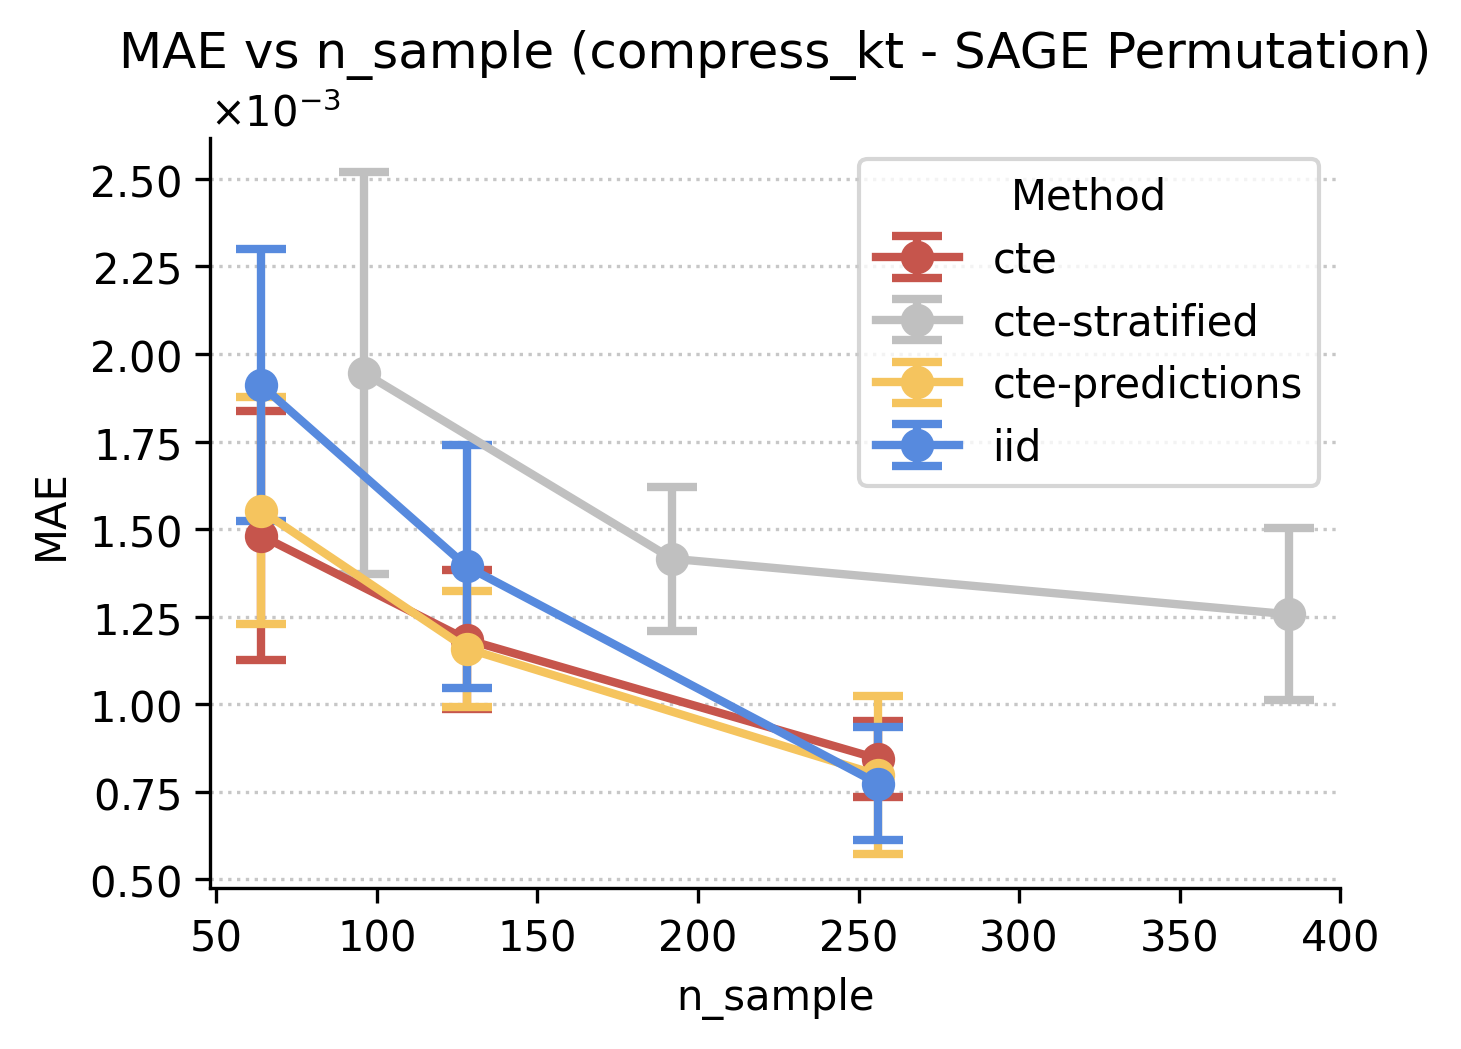

In [13]:
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=300)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

colors = {
    "iid_sage_permutation": "#578ade",
    "cte_sage_permutation": "#c6554c",
    "cte_stratified_sage_permutation": "#c0c0c0",
    "cte_with_predictions_sage_permutation": "#F5C45E",
}

for method in agg_df['method'].unique():
    method_data = agg_df[agg_df['method'] == method]
    x = method_data['n_sample']
    y = method_data['mean']
    yerr = method_data['std']
    ax.errorbar(
        x=x, y=y, yerr=yerr,
        fmt='o-', label=method_labels.get(method, method), 
        color=colors.get(method, None),  
        markersize=7, capsize=6, linewidth=2, capthick = 2
    )

ax.set_xlabel("n_sample")
ax.set_ylabel("MAE")
ax.set_title("MAE vs n_sample (compress_kt - SAGE Permutation)")
ax.legend(title="Method")
ax.grid(axis='y', linestyle='dotted', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


SHAP + Kernel

In [14]:
times_cte_info_ = times_cte_info[
    times_cte_info['method'].isin([
        'cte_shap_kernel',
        'cte_with_predictions_shap_kernel',
        'cte_stratified_shap_kernel',
        'iid_shap_kernel'
    ])
]

In [15]:
ground_truth = values_gt['shap_kernel']

mae_list = []

method_indices = {method: 0 for method in values_cte.keys()}

for _, row in times_cte_info_.iterrows():
    method = row['method']
    
    current_index = method_indices[method]
    values_cte_ = values_cte[method][current_index]
    
    method_indices[method] += 1
    
    mae = metric_mae(values_cte_, ground_truth)
    mae_list.append(mae)  

times_cte_info_['mae'] = mae_list

times_cte_info_

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g,mae
1,heloc,0,cte_shap_kernel,323.614055,0.006613,1975,64,1,0.007830
3,heloc,0,cte_with_predictions_shap_kernel,322.845884,0.003151,1975,64,1,0.007699
5,heloc,0,cte_stratified_shap_kernel,377.744061,0.024590,1975,96,1,0.009230
7,heloc,0,iid_shap_kernel,330.191841,0.000101,1975,64,1,0.008443
9,heloc,1,cte_shap_kernel,327.769080,0.014236,1975,64,1,0.007819
11,heloc,1,cte_with_predictions_shap_kernel,328.979205,0.008682,1975,64,1,0.007800
13,heloc,1,cte_stratified_shap_kernel,385.199823,0.009794,1975,96,1,0.008917
15,heloc,1,iid_shap_kernel,316.503268,0.000083,1975,64,1,0.009672
17,heloc,2,cte_shap_kernel,317.238720,0.013270,1975,64,1,0.007533
19,heloc,2,cte_with_predictions_shap_kernel,316.045646,0.003409,1975,64,1,0.007770


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

agg_df = times_cte_info_.groupby(['method', 'n_sample']).agg(
    mean=('mae', 'mean'),
    std=('mae', 'std')
).reset_index()

method_labels = {
    "iid_shap_kernel": "iid",
    "cte_shap_kernel": "cte",
    "cte_with_predictions_shap_kernel": "cte-predictions",
    "cte_stratified_shap_kernel": "cte-stratified",
}

label=method_labels.get(method, method)

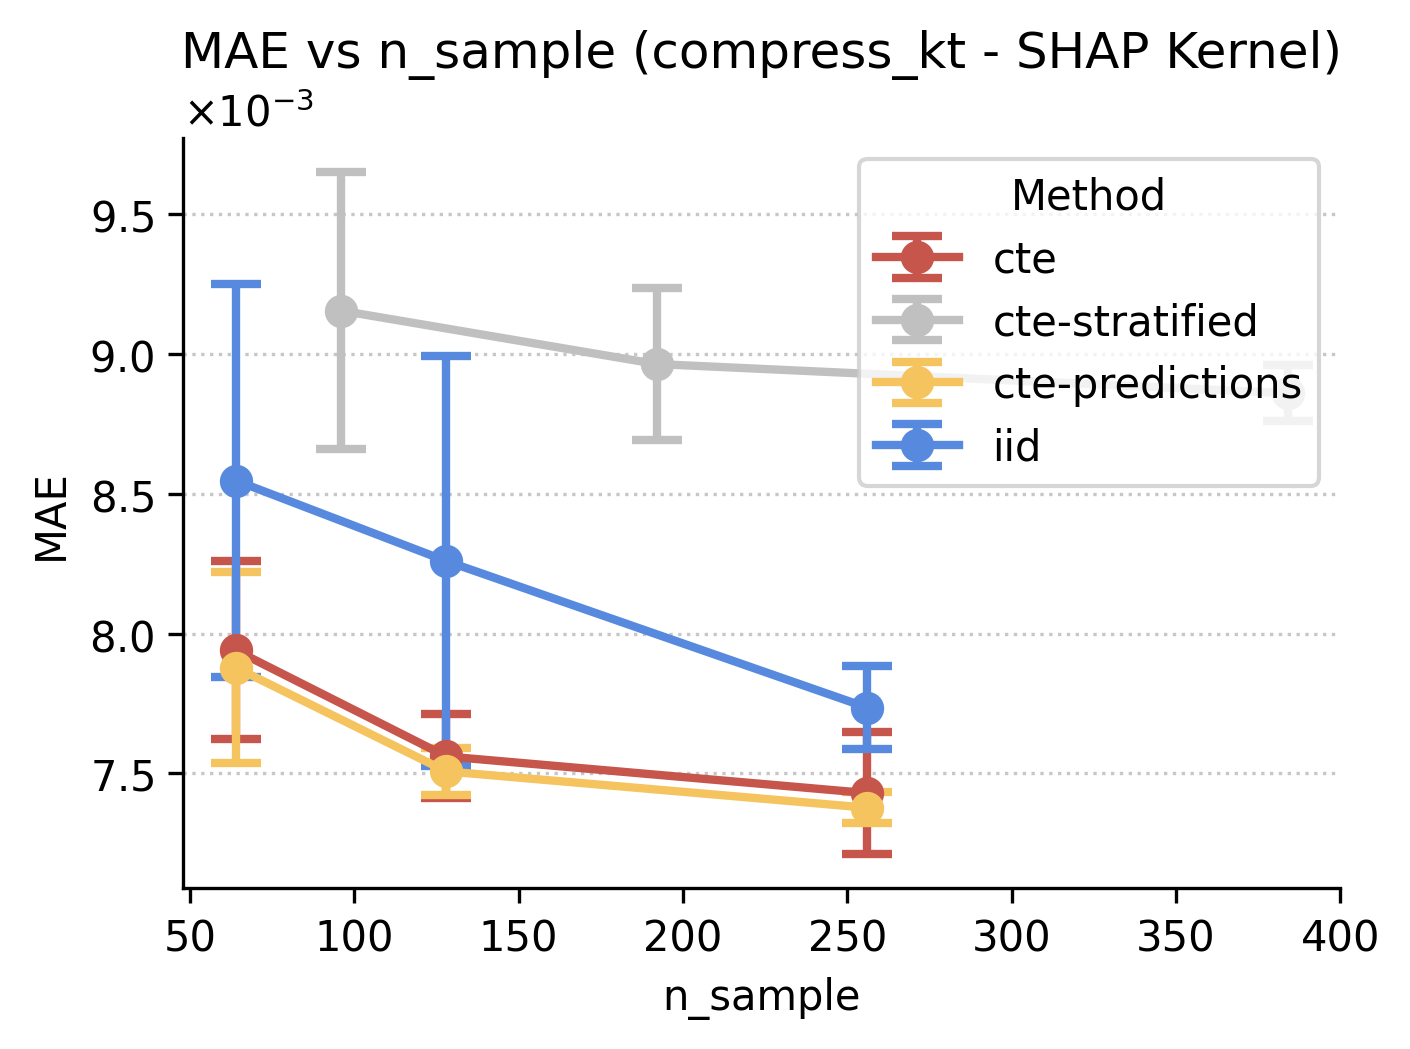

In [17]:
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=300)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

colors = {
    "iid_shap_kernel": "#578ade",
    "cte_shap_kernel": "#c6554c",
    "cte_stratified_shap_kernel": "#c0c0c0",
    "cte_with_predictions_shap_kernel": "#F5C45E",
}

for method in agg_df['method'].unique():
    method_data = agg_df[agg_df['method'] == method]
    x = method_data['n_sample']
    y = method_data['mean']
    yerr = method_data['std']
    ax.errorbar(
        x=x, y=y, yerr=yerr,
        fmt='o-', label=method_labels.get(method, method), 
        color=colors.get(method, None),  
        markersize=7, capsize=6, linewidth=2, capthick = 2
    )

ax.set_xlabel("n_sample")
ax.set_ylabel("MAE")
ax.set_title("MAE vs n_sample (compress_kt - SHAP Kernel)")
ax.legend(title="Method")
ax.grid(axis='y', linestyle='dotted', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
